# Experiments for Randers-Finsler HMC

In [1]:
import torch
from torch import Tensor
from geodesic_toolbox import ExplicitRHMCSampler, ExplicitFHMC, ImplicitFHMCUnbiased
from geodesic_toolbox.solvers import GEORCEFinsler
from geodesic_toolbox.cometric import DualRandersMetrics, RandersMetrics, RandersCentroidRotational, IdentityCoMetric, OneForm_zero, MyCentroidsCometric
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import gaussian_kde
import warnings
from matplotlib import cm

## 1 - Definition of Randers Metric

In [2]:
# Generate data as an annulus
n = 1000
theta = torch.rand(n) * 2 * np.pi
r = torch.sqrt(torch.rand(n) * 0.5 + 0.5)
x = r * torch.cos(theta)
y = r * torch.sin(theta)
X = torch.stack([x, y], dim=1)

In [3]:
beta = 0.9

randers_metric = RandersCentroidRotational(
    centroids=X,
    cometric_centroids=IdentityCoMetric()(X),
    temperature_scale=0.1,
    K=-1,
    beta = beta
)
randers_cometric = DualRandersMetrics(randers_metric)

In [4]:
# omega = OneForm_zero()
# base_cometric = MyCentroidsCometric(
#     centroids=X,
#     cometric_centroids=IdentityCoMetric()(X),
#     temperature_scale=0.1,
#     K=-1
# )
# randers_metric = RandersMetrics(base_cometric, omega)
# randers_cometric = DualRandersMetrics(randers_metric)

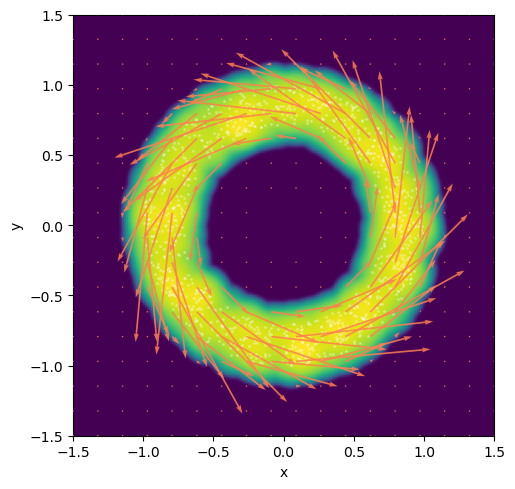

In [5]:
eps = 1e-6

N = 200
x = torch.linspace(-1.5, 1.5, N)
y = torch.linspace(-1.5, 1.5, N)
xx, yy = torch.meshgrid(x, y, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

grid_fine   = 100  # resolution for contour
grid_coarse = 18   # resolution for quiver

xg = np.linspace(-1.5, 1.5, grid_fine)
yg = np.linspace(-1.5, 1.5, grid_fine)
xx, yy = np.meshgrid(xg, yg)
pts_flat = np.stack([xx.ravel(), yy.ravel()], axis=1)

xg_c = np.linspace(-1.5, 1.5, grid_coarse)
yg_c = np.linspace(-1.5, 1.5, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)
mask_c = np.linalg.norm(pts_c_flat, axis=1) > 0.15   # skip near-origin for quiver

with torch.no_grad():
    pts_tensor   = torch.tensor(pts_flat, dtype=torch.float32)
    pts_c_tensor = torch.tensor(pts_c_flat[mask_c], dtype=torch.float32)

    # log det G(z) — high where metric is large (far from data), low in the annulus
    logdet_vals = randers_metric.base_cometric.logdet(pts_tensor).numpy()
    # ω vector field from the Randers metric
    omega_vecs  = randers_metric.omega(pts_c_tensor).detach().numpy()

with torch.no_grad():
    g_inv_diag = randers_metric.base_cometric(pts.float())
    det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + eps)

det_G = det_G.reshape(N, N).numpy()
log_det_G = np.log(det_G + eps)

finite = log_det_G[np.isfinite(log_det_G)]
vmax = np.percentile(finite, 100)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    log_det_G.T,
    origin="lower",
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap="viridis",
    vmin=finite.min(),
    vmax=vmax,
)

# --- Data points (annulus) ---
ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(),
           s=1.5, c="white", alpha=0.25, zorder=2, label="data")

# --- ω quiver ---
ax.quiver(
    pts_c_flat[mask_c, 0], pts_c_flat[mask_c, 1],
    omega_vecs[:, 0],      omega_vecs[:, 1],
    color="coral", alpha=0.85, zorder=3,
    angles="xy", scale_units="xy", scale=5, width=0.004,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()


## 2 - Hamiltonian trajectories for Randers geodesics

In [6]:
l = 50
N_fx = 6
gamma = 0.01
N_run = 1

sampler = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True,
    skip_acceptance = True
    )

In [7]:
z_0 = torch.tensor([[0.,1.]])
#z_1 = z_0.clone()
v_0 = torch.tensor([[1., 0.]])
p_0 = sampler.legendre(v_0, z_0)
#p_1 = p_0.clone()
#traj = sampler.leapfrog(z_0, p_0, z_1, p_1, return_traj=True)
dirs = torch.ones(z_0.shape[0])
traj = sampler.leapfrog(z_0, p_0, dirs, return_traj=True)

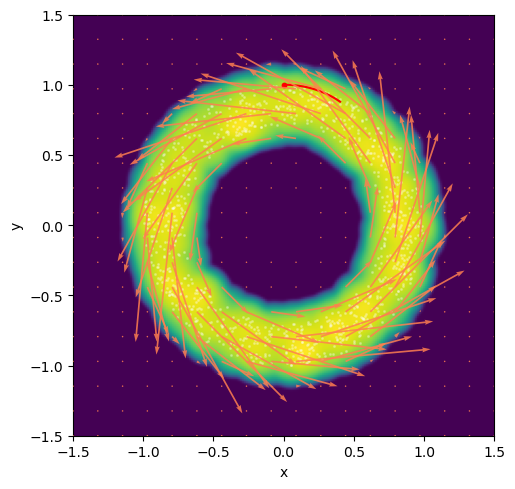

In [8]:
eps = 1e-6

N = 200
x = torch.linspace(-1.5, 1.5, N)
y = torch.linspace(-1.5, 1.5, N)
xx, yy = torch.meshgrid(x, y, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

grid_fine   = 100  # resolution for contour
grid_coarse = 18   # resolution for quiver

xg = np.linspace(-1.5, 1.5, grid_fine)
yg = np.linspace(-1.5, 1.5, grid_fine)
xx, yy = np.meshgrid(xg, yg)
pts_flat = np.stack([xx.ravel(), yy.ravel()], axis=1)

xg_c = np.linspace(-1.5, 1.5, grid_coarse)
yg_c = np.linspace(-1.5, 1.5, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)
mask_c = np.linalg.norm(pts_c_flat, axis=1) > 0.15   # skip near-origin for quiver

with torch.no_grad():
    pts_tensor   = torch.tensor(pts_flat, dtype=torch.float32)
    pts_c_tensor = torch.tensor(pts_c_flat[mask_c], dtype=torch.float32)

    # log det G(z) — high where metric is large (far from data), low in the annulus
    logdet_vals = randers_metric.base_cometric.logdet(pts_tensor).numpy()
    # ω vector field from the Randers metric
    omega_vecs  = randers_metric.omega(pts_c_tensor).detach().numpy()

with torch.no_grad():
    g_inv_diag = randers_metric.base_cometric(pts.float())
    det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + eps)

det_G = det_G.reshape(N, N).numpy()
log_det_G = np.log(det_G + eps)

finite = log_det_G[np.isfinite(log_det_G)]
vmax = np.percentile(finite, 100)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    log_det_G.T,
    origin="lower",
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap="viridis",
    vmin=finite.min(),
    vmax=vmax,
)

# --- Data points (annulus) ---
ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(),
           s=1.5, c="white", alpha=0.25, zorder=2, label="data")

# --- ω quiver ---
ax.quiver(
    pts_c_flat[mask_c, 0], pts_c_flat[mask_c, 1],
    omega_vecs[:, 0],      omega_vecs[:, 1],
    color="coral", alpha=0.85, zorder=3,
    angles="xy", scale_units="xy", scale=5, width=0.004,
)

# --- traj ---
ax.plot(traj[0][0,:,0],traj[0][0,:,1], c="red" )

# --- start point ---
ax.scatter(traj[0][0,0,0],traj[0][0,0,1], c="red", s = 10)

ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()


## 3- Tests for FHMC algorithm with difference acceptation rates

## 3.1. FHMC without rejection (or geodesic Random Walk)

In [9]:
l = 5
N_fx = 6
gamma = 0.001
N_run = 50

sampler = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True,
    skip_acceptance = True
    )

Initial momentum and velocity distribution

In [10]:
z_0 = torch.tensor([[0., 1.]]*10**4)

G_star = randers_cometric.G_star(z_0)[0,...]
w_star = randers_cometric.omega_star(z_0)[0,...]
p_0 = sampler.sample_momentum(z_0)
v_0 = sampler.reversed_legendre(p_0, z_0)

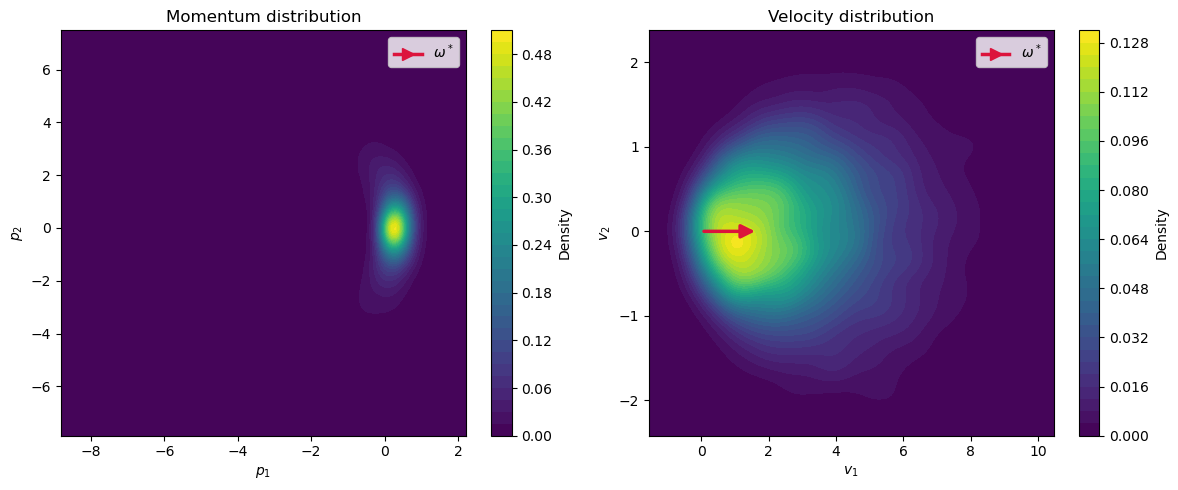

In [11]:
import matplotlib.lines as mlines

# Convert to numpy
p_np = p_0.detach().cpu().numpy()
v_np = v_0.detach().cpu().numpy()
w_np = w_star.detach().cpu().numpy()

# --- Auto-adapt bounds: 0.5–99.5 percentile + 15% margin ---
def auto_bounds(data, q_lo=0.5, q_hi=99.5, margin=0.15):
    lo = np.percentile(data, q_lo, axis=0)
    hi = np.percentile(data, q_hi, axis=0)
    span = hi - lo
    return lo - margin * span, hi + margin * span

p_lo, p_hi = auto_bounds(p_np)
v_lo, v_hi = auto_bounds(v_np)

grid_size = 150

def make_grid(lo, hi, n=grid_size):
    xx, yy = np.meshgrid(np.linspace(lo[0], hi[0], n), np.linspace(lo[1], hi[1], n))
    return xx, yy, np.vstack([xx.ravel(), yy.ravel()])

p_xx, p_yy, p_pts = make_grid(p_lo, p_hi)
v_xx, v_yy, v_pts = make_grid(v_lo, v_hi)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def plot_panel(ax, data, xx, yy, pts, lo, hi, xlabel, ylabel, title, arrow_w):
    kde = gaussian_kde(data.T)
    zz = kde(pts).reshape(xx.shape)
    cf = ax.contourf(xx, yy, zz, levels=40, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Density")

    # Arrow scaled to 20% of the plot span, unit-direction normalised
    scale = 0.2 * np.mean(hi - lo) / (np.linalg.norm(arrow_w) + 1e-12)
    dx, dy = scale * arrow_w[0], scale * arrow_w[1]
    ax.annotate("", xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="crimson",
                                lw=2.5, mutation_scale=20))

    proxy = mlines.Line2D([], [], color="crimson", lw=2.5,
                          marker=">", markersize=9, label=r"$\omega^*$")
    ax.legend(handles=[proxy], loc="upper right", framealpha=0.8)
    ax.set_xlim(lo[0], hi[0])
    ax.set_ylim(lo[1], hi[1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plot_panel(axs[0], p_np, p_xx, p_yy, p_pts, p_lo, p_hi,
           "$p_1$", "$p_2$", "Momentum distribution", w_np)
plot_panel(axs[1], v_np, v_xx, v_yy, v_pts, v_lo, v_hi,
           "$v_1$", "$v_2$", "Velocity distribution", w_np)

plt.tight_layout()
plt.show()

Full trajectories

In [12]:
n_traj = 20
traj = sampler.sample(
    z_0 = torch.tensor([[0., 1.]]*n_traj),
    return_traj= True, 
    progress=True
)

Sampling: 100%|██████████| 50/50 [00:11<00:00,  4.38steps/s, acceptance_rate=1]


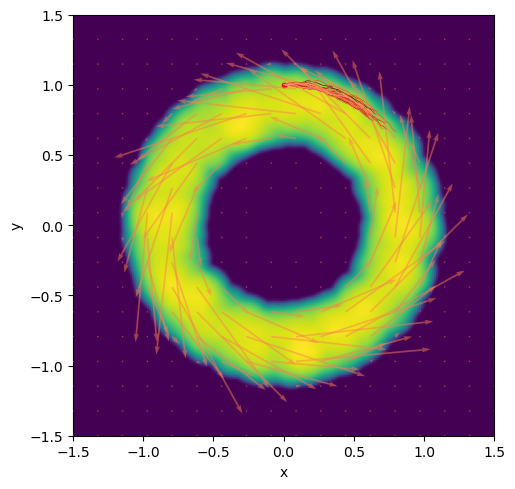

In [13]:
eps = 1e-6

N = 200
x = torch.linspace(-1.5, 1.5, N)
y = torch.linspace(-1.5, 1.5, N)
xx, yy = torch.meshgrid(x, y, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

grid_fine   = 100  # resolution for contour
grid_coarse = 18   # resolution for quiver

xg = np.linspace(-1.5, 1.5, grid_fine)
yg = np.linspace(-1.5, 1.5, grid_fine)
xx, yy = np.meshgrid(xg, yg)
pts_flat = np.stack([xx.ravel(), yy.ravel()], axis=1)

xg_c = np.linspace(-1.5, 1.5, grid_coarse)
yg_c = np.linspace(-1.5, 1.5, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)
mask_c = np.linalg.norm(pts_c_flat, axis=1) > 0.15   # skip near-origin for quiver

with torch.no_grad():
    pts_tensor   = torch.tensor(pts_flat, dtype=torch.float32)
    pts_c_tensor = torch.tensor(pts_c_flat[mask_c], dtype=torch.float32)

    # log det G(z) — high where metric is large (far from data), low in the annulus
    logdet_vals = randers_metric.base_cometric.logdet(pts_tensor).numpy()
    # ω vector field from the Randers metric
    omega_vecs  = randers_metric.omega(pts_c_tensor).detach().numpy()

with torch.no_grad():
    g_inv_diag = randers_metric.base_cometric(pts.float())
    det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + eps)

det_G = det_G.reshape(N, N).numpy()
log_det_G = np.log(det_G + eps)

finite = log_det_G[np.isfinite(log_det_G)]
vmax = np.percentile(finite, 100)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    log_det_G.T,
    origin="lower",
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap="viridis",
    vmin=finite.min(),
    vmax=vmax,
)

# --- ω quiver ---
ax.quiver(
    pts_c_flat[mask_c, 0], pts_c_flat[mask_c, 1],
    omega_vecs[:, 0],      omega_vecs[:, 1],
    color="coral", alpha=0.5, zorder=3,
    angles="xy", scale_units="xy", scale=5, width=0.004,
)

# -- Trajs --

# Use a more red-based colormap, e.g., 'Reds'
colors = cm.Reds(np.linspace(0.3, 1, traj.shape[0]))  # skip the lightest reds
for i in range(traj.shape[0]):
    ax.plot(traj[i,:,0], traj[i,:,1], c=colors[-i], linewidth = 0.5)

# --- start point ---
ax.scatter(traj[0,0,0],traj[0,0,1], c="red", s = 10)

ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()


## 3.2. FHMC : acceptation ratio as likelihood ratio

In [14]:
l = 1
N_fx = 6
gamma = 0.01
N_run = 100

sampler = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True, 
    reduced_flip= False
    )

sampler_optimized = ImplicitFHMCUnbiased(
    randers_cometric,
    l, 
    N_fx,
    gamma, 
    N_run, 
    pbar = True
    )

In [15]:
n_traj = 200
traj, acc, flip = sampler.sample(
    z_0 = torch.tensor([[0.,0.85]]*n_traj),
    return_traj= True, 
    return_acceptance= True,
    progress = True,
    return_flip = True
)
print(f"Acceptance rate: {acc:.4f}")
print(f"Momentum flip rate: {flip:.4f}")

Sampling: 100%|██████████| 100/100 [00:09<00:00, 10.43steps/s, acceptance_rate=0.987]

Acceptance rate: 0.9871
Momentum flip rate: 0.0129


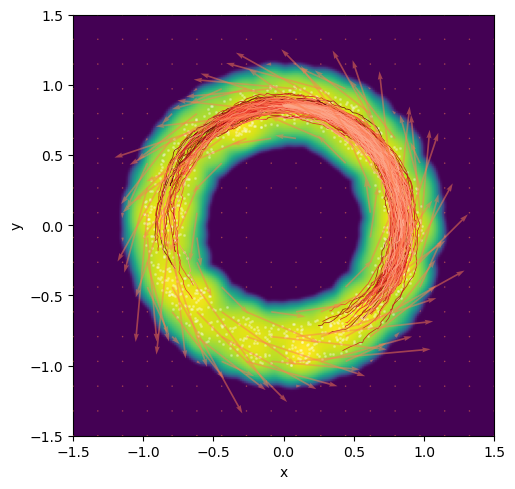

In [16]:
eps = 1e-6

N = 200
x = torch.linspace(-1.5, 1.5, N)
y = torch.linspace(-1.5, 1.5, N)
xx, yy = torch.meshgrid(x, y, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

grid_fine   = 100  # resolution for contour
grid_coarse = 18   # resolution for quiver

xg = np.linspace(-1.5, 1.5, grid_fine)
yg = np.linspace(-1.5, 1.5, grid_fine)
xx, yy = np.meshgrid(xg, yg)
pts_flat = np.stack([xx.ravel(), yy.ravel()], axis=1)

xg_c = np.linspace(-1.5, 1.5, grid_coarse)
yg_c = np.linspace(-1.5, 1.5, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)
mask_c = np.linalg.norm(pts_c_flat, axis=1) > 0.15   # skip near-origin for quiver

with torch.no_grad():
    pts_tensor   = torch.tensor(pts_flat, dtype=torch.float32)
    pts_c_tensor = torch.tensor(pts_c_flat[mask_c], dtype=torch.float32)

    # log det G(z) — high where metric is large (far from data), low in the annulus
    logdet_vals = randers_metric.base_cometric.logdet(pts_tensor).numpy()
    # ω vector field from the Randers metric
    omega_vecs  = randers_metric.omega(pts_c_tensor).detach().numpy()

with torch.no_grad():
    g_inv_diag = randers_metric.base_cometric(pts.float())
    det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + eps)

det_G = det_G.reshape(N, N).numpy()
log_det_G = np.log(det_G + eps)

finite = log_det_G[np.isfinite(log_det_G)]
vmax = np.percentile(finite, 100)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    log_det_G.T,
    origin="lower",
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap="viridis",
    vmin=finite.min(),
    vmax=vmax,
)

# --- Data points (annulus) ---
ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(),
           s=1.5, c="white", alpha=0.25, zorder=2, label="data")

# --- ω quiver ---
ax.quiver(
    pts_c_flat[mask_c, 0], pts_c_flat[mask_c, 1],
    omega_vecs[:, 0],      omega_vecs[:, 1],
    color="coral", alpha=0.5, zorder=3,
    angles="xy", scale_units="xy", scale=5, width=0.004,
)

# -- Trajs --

# Use a more red-based colormap, e.g., 'Reds'
colors = cm.Reds(np.linspace(0.3, 1, traj.shape[0]))  # skip the lightest reds
for i in range(traj.shape[0]):
    ax.plot(traj[i,:,0], traj[i,:,1], c=colors[-i], linewidth = 0.5)

# --- start point ---
ax.scatter(traj[0,0,0],traj[0,0,1], c="red", s = 10)

ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()


In [17]:
n_traj = 200

traj, acc, flip = sampler_optimized.sample(
    z_0 = torch.tensor([[0.,0.85]]*n_traj),
    return_traj= True, 
    return_acceptance= True,
    progress = True,
    return_flip = True
)
print(f"Acceptance rate: {acc:.4f}")
print(f"Momentum flip rate: {flip:.4f}")

Sampling: 100%|██████████| 100/100 [00:17<00:00,  5.64steps/s, acceptance_rate=0.989]

Acceptance rate: 0.9887
Momentum flip rate: 0.0097


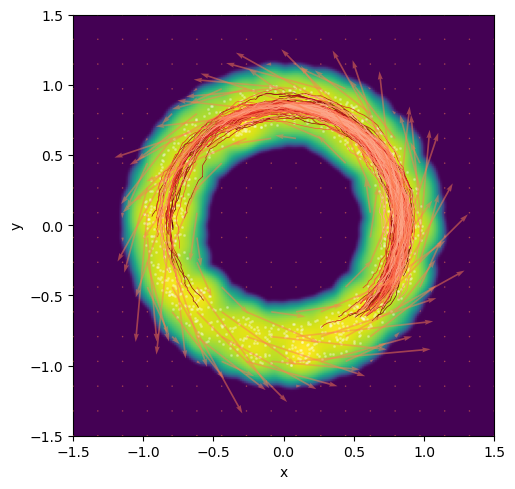

In [18]:
eps = 1e-6

N = 200
x = torch.linspace(-1.5, 1.5, N)
y = torch.linspace(-1.5, 1.5, N)
xx, yy = torch.meshgrid(x, y, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

grid_fine   = 100  # resolution for contour
grid_coarse = 18   # resolution for quiver

xg = np.linspace(-1.5, 1.5, grid_fine)
yg = np.linspace(-1.5, 1.5, grid_fine)
xx, yy = np.meshgrid(xg, yg)
pts_flat = np.stack([xx.ravel(), yy.ravel()], axis=1)

xg_c = np.linspace(-1.5, 1.5, grid_coarse)
yg_c = np.linspace(-1.5, 1.5, grid_coarse)
xx_c, yy_c = np.meshgrid(xg_c, yg_c)
pts_c_flat = np.stack([xx_c.ravel(), yy_c.ravel()], axis=1)
mask_c = np.linalg.norm(pts_c_flat, axis=1) > 0.15   # skip near-origin for quiver

with torch.no_grad():
    pts_tensor   = torch.tensor(pts_flat, dtype=torch.float32)
    pts_c_tensor = torch.tensor(pts_c_flat[mask_c], dtype=torch.float32)

    # log det G(z) — high where metric is large (far from data), low in the annulus
    logdet_vals = randers_metric.base_cometric.logdet(pts_tensor).numpy()
    # ω vector field from the Randers metric
    omega_vecs  = randers_metric.omega(pts_c_tensor).detach().numpy()

with torch.no_grad():
    g_inv_diag = randers_metric.base_cometric(pts.float())
    det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + eps)

det_G = det_G.reshape(N, N).numpy()
log_det_G = np.log(det_G + eps)

finite = log_det_G[np.isfinite(log_det_G)]
vmax = np.percentile(finite, 100)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    log_det_G.T,
    origin="lower",
    extent=[-1.5, 1.5, -1.5, 1.5],
    cmap="viridis",
    vmin=finite.min(),
    vmax=vmax,
)

# --- Data points (annulus) ---
ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(),
           s=1.5, c="white", alpha=0.25, zorder=2, label="data")

# --- ω quiver ---
ax.quiver(
    pts_c_flat[mask_c, 0], pts_c_flat[mask_c, 1],
    omega_vecs[:, 0],      omega_vecs[:, 1],
    color="coral", alpha=0.5, zorder=3,
    angles="xy", scale_units="xy", scale=5, width=0.004,
)

# -- Trajs --

# Use a more red-based colormap, e.g., 'Reds'
colors = cm.Reds(np.linspace(0.3, 1, traj.shape[0]))  # skip the lightest reds
for i in range(traj.shape[0]):
    ax.plot(traj[i,:,0], traj[i,:,1], c=colors[-i], linewidth = 0.5)

# --- start point ---
ax.scatter(traj[0,0,0],traj[0,0,1], c="red", s = 10)

ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()
